In [2]:
import sys
sys.path.append('..')
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

from expl_perf_drop.explainers import CGExplainerDR
from expl_perf_drop.utils import Graph

/home/petermcgor/miniconda3/envs/expl_perf_drop/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
! ls ..

dowhy		  environment.yml  expl_perf_drop  README.md	     setup.py
environment2.yml  examples	   LICENSE	   requirements.txt


## Make Some Synthetic Data

In [4]:
# mapping of nodes in the causal graph to column names in a dataframe.
# here, all nodes are scalars, but they can also be vector-valued
VAR_CATEGORIES = { 
    'G': ['G'],
    'X1': ['X1'],
    'X2': ['X2'],
    'X3': ['X3'],
    'Y': ['Y']
}

# define the causal graph
GRAPH = Graph(
    nodes= list(VAR_CATEGORIES.keys()),
    edges=[
        ('G', 'Y'),
        ('G', 'X2'),
        ('G', 'X3'),
        ('Y', 'X1'), 
        ('Y', 'X2'), 
        ('Y', 'X3'), 
    ]
)

In [5]:
# this is the synthetic dataset from the appendix of the paper
def generate(n, rng, q = 0.9, y_noise = 0.25, mu_add = 3, x1_weight = 1.0):
    G = rng.random(size = (n, 1)) >= 0.5
    Y = np.logical_xor(G, rng.random(size = (n, 1)) >= q)     
    Y_noised_1 = np.logical_xor(Y, rng.random(size = (n, 1)) <= y_noise)
    Y_noised_2 = np.logical_xor(Y, rng.random(size = (n, 1)) <= y_noise)   
    Y_noised_3 = np.logical_xor(Y, rng.random(size = (n, 1)) <= y_noise)   

    X1 = rng.normal(loc = x1_weight * Y_noised_1, size = (n, 1))
    X2 = rng.normal(loc = Y_noised_2 + G, size = (n, 1))
    X3 = rng.normal(loc = Y_noised_3 + mu_add * G, size = (n, 1))
    X = np.concatenate([X1, X2, X3], axis = -1)

    return data_to_df(X, G.squeeze(), Y.squeeze())

def data_to_df(X, G, Y):
    df = pd.DataFrame({'G': G.astype(int), 'Y': Y.astype(int)})
    for i in range(1, X.shape[1] + 1):
        df[f'X{i}'] = X[:, i-1]
    return df

# make dataframes for source and target domains
source_df = generate(20000, np.random.RandomState(0))
source_train_df, source_eval_df = train_test_split(source_df, random_state = 0, shuffle = True, test_size = 0.25)

target_df = generate(20000, np.random.RandomState(1), q = 0.1)
target_train_df, target_eval_df = train_test_split(target_df, random_state = 1, shuffle = True, test_size = 0.25)

In [6]:
# all dataframes must have column names corresponding to all values in the VAR_CATEGORIES mapping
target_train_df

,G,Y,X1,X2,X3
18960,0,1,0.769550,-0.616149,0.663881
11353,0,1,-1.166020,0.860702,1.968601
7449,0,1,-0.070470,0.378767,-0.065953
14308,1,0,0.510399,-0.016011,2.110591
11889,0,1,0.446860,1.046087,0.410305
...,...,...,...,...,...
10955,1,0,0.529000,1.400120,2.647361
17289,1,0,-1.092225,0.876356,2.781320
5192,1,0,1.587095,-0.498254,2.966031
12172,1,0,-0.156151,2.756553,4.318010


## Training/Loading the Model

In [7]:
# Here, we use an XGBoost model, but any model can be used as long as you have a compatible metric function
from xgboost.sklearn import XGBClassifier
from sklearn.model_selection import GridSearchCV

TRAIN_FEATURES = ['X1', 'X2', 'X3']

model = GridSearchCV(
        estimator = XGBClassifier(random_state = 42, n_jobs = -1),
        param_grid = {'max_depth': [1, 2, 3, 4, 5]},
        scoring = 'roc_auc_ovr',
        cv = 3,
        refit = True
    ).fit(source_train_df[TRAIN_FEATURES], source_train_df['Y'])

## Define the Metric Function

In [8]:
# a metric function takes in:
## in a model, 
## a dataframe, 
## a set of column names to be passed into the model,
## a vector of weights,
## and potentially a target name,
## and returns a scalar.

from sklearn.metrics import brier_score_loss

# implemented metrics for sklearn models can also be found in expl_perf_drop.metrics
def brier(model, data, subset_cols = None, weight = None, target_name = 'Y'):
    data_input = data[subset_cols] if subset_cols is not None else data
    return brier_score_loss(data[target_name], model.predict_proba(data_input)[:, 1], sample_weight = weight)

## Getting the Explanation

In [8]:
exp = CGExplainerDR(GRAPH, source_train_df, source_eval_df, target_train_df, target_eval_df,
        TRAIN_FEATURES, VAR_CATEGORIES, target_name = 'Y'
)

In [9]:
# performance of your model on the source and target
perfs = exp.get_perf_on_sets(model, metric = brier)
perfs

{'source': 0.09982808262537017, 'target': 0.556171176300962}

In [10]:
# all possilble shifts which the graph entails
exp.get_all_possible_shifts()

['G',
 (frozenset({'Y'}), 'X1'),
 (frozenset({'G', 'Y'}), 'X2'),
 (frozenset({'G', 'Y'}), 'X3'),
 (frozenset({'G'}), 'Y')]

In [11]:
# get the explanation!
res = exp.explain(model, metric = brier)
res

Evaluate set function: 0it [00:00, ?it/s]

_delta []
Features subset ['X1', 'X2', 'X3'] weights [1. 1. 1. ... 1. 1. 1.]


Evaluate set function: 1it [06:19, 379.96s/it]

_delta [(frozenset({'G'}), 'Y')]
Features subset ['X1', 'X2', 'X3'] weights [0.11430791 0.11430791 0.11152165 ... 0.11152165 0.11430791 0.11152165]


Evaluate set function: 2it [23:39, 767.76s/it]

...

Evaluate set function: 31it [30:37,  1.76s/it]

_delta ['G', (frozenset({'Y'}), 'X1'), (frozenset({'Y', 'G'}), 'X2'), (frozenset({'Y', 'G'}), 'X3'), (frozenset({'G'}), 'Y')]
Features subset ['X1', 'X2', 'X3'] weights [0.08384072 0.06029316 0.13194598 ... 0.08182499 0.08192047 0.08413272]


Evaluate set function: 32it [30:38, 57.47s/it]


Finished evaluating 32 subsets. {(0, 0, 0, 0, 0): 0.0, (0, 0, 0, 0, 1): 0.44655460789495854, (0, 0, 0, 1, 0): 0.001157425301972978, (0, 0, 0, 1, 1): 0.45035993939442603, (0, 0, 1, 0, 0): 0.005181700370928827, (0, 0, 1, 0, 1): 0.45586462355780694, (0, 0, 1, 1, 0): 0.006095092545117239, (0, 0, 1, 1, 1): 0.4590907271741382, (0, 1, 0, 0, 0): -2.091394309389205e-05, (0, 1, 0, 0, 1): 0.4465628888111329, (0, 1, 0, 1, 0): 0.001153791240095195, (0, 1, 0, 1, 1): 0.45032121386105056, (0, 1, 1, 0, 0): 0.005084477301221774, (0, 1, 1, 0, 1): 0.45575693331145056, (0, 1, 1, 1, 0): 0.006006070462784424, (0, 1, 1, 1, 1): 0.4589614414861349, (1, 0, 0, 0, 0): 1.8382612063869153e-05, (1, 0, 0, 0, 1): 0.44658958743014526, (1, 0, 0, 1, 0): 0.0011663116534988138, (1, 0, 0, 1, 1): 0.4505388982711018, (1, 0, 1, 0, 0): 0.0051635680057291605, (1, 0, 1, 0, 1): 0.45577113797662056, (1, 0, 1, 1, 0): 0.0060646629932502305, (1, 0, 1, 1, 1): 0.4591242803620696, (1, 1, 0, 0, 0): 4.529356829360842e-06, (1, 1, 0, 0, 1): 0

P(G)           0.000023
P(X1 | Y)     -0.000062
P(X2 | G,Y)    0.006913
P(X3 | G,Y)    0.002282
P(Y | G)       0.449843
dtype: float64

In [11]:
# optionally, can re-scale the explanation to ensure they sum to the total shift (which may not happen due to estimation error)
exp.scale(res, perfs)

P(G)           0.000046
P(X1 | Y)      0.000220
P(X2 | G,Y)   -0.015478
P(X3 | G,Y)    0.003610
P(Y | G)       0.468020
dtype: float64

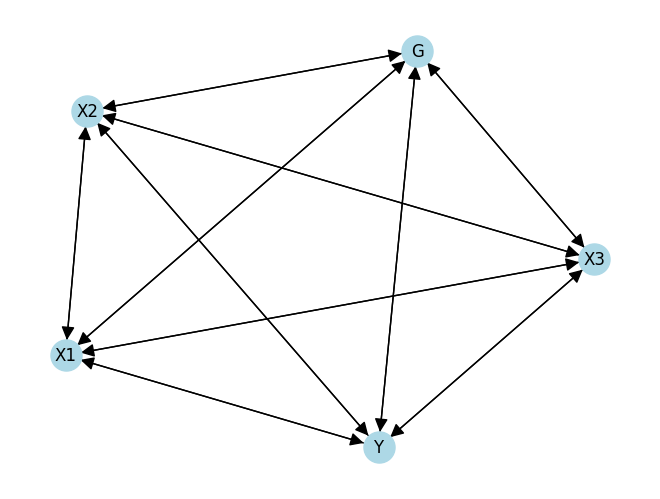

In [10]:
# Pedro palys with the graph
import networkx as nx
import matplotlib.pyplot as plt


# Draw the graph
nx.draw(GRAPH.to_all_conds(), with_labels=True, node_color='lightblue', 
        node_size=500, arrowsize=20)
plt.show()


In [23]:
# Lets try other shifts
target_df_mu = generate(20000, np.random.RandomState(1), mu_add=0)
target_train_df, target_eval_df = train_test_split(target_df_mu, random_state = 1, shuffle = True, test_size = 0.25)

In [24]:
exp_mu = CGExplainerDR(GRAPH, source_train_df, source_eval_df, target_train_df, target_eval_df,
        TRAIN_FEATURES, VAR_CATEGORIES, target_name = 'Y'
)

In [25]:
# performance of your model on the source and target
perfs = exp_mu.get_perf_on_sets(model, metric = brier)
perfs

{'source': 0.09982808262537017, 'target': 0.32774653166695905}

In [26]:
exp_mu.get_all_possible_shifts()

['G',
 (frozenset({'Y'}), 'X1'),
 (frozenset({'G', 'Y'}), 'X2'),
 (frozenset({'G', 'Y'}), 'X3'),
 (frozenset({'G'}), 'Y')]

In [27]:
res = exp_mu.explain(model, metric = brier)
res

Evaluate set function: 32it [00:00, 11472.58it/s]


_delta []
Features subset ['X1', 'X2', 'X3'] weights [1. 1. 1. ... 1. 1. 1.]
_delta [(frozenset({'G'}), 'Y')]
Features subset ['X1', 'X2', 'X3'] weights [1.00294292 1.00294292 0.99711239 ... 0.99711239 1.00294292 0.99711239]
_delta [(frozenset({'Y', 'G'}), 'X3')]
Features subset ['X1', 'X2', 'X3'] weights [1.07357979e+01 3.08199809e-03 8.69457543e-01 ... 9.87476707e-01
 9.90993460e-04 8.89998794e-01]
_delta [(frozenset({'Y', 'G'}), 'X3'), (frozenset({'G'}), 'Y')]
Features subset ['X1', 'X2', 'X3'] weights [1.07673925e+01 3.09106816e-03 8.66946892e-01 ... 9.84625262e-01
 9.93909874e-04 8.87428827e-01]
_delta [(frozenset({'Y', 'G'}), 'X2')]
Features subset ['X1', 'X2', 'X3'] weights [0.95275313 0.68852985 1.2805115  ... 1.03223872 0.79814911 0.89136523]
_delta [(frozenset({'G', 'Y'}), 'X2'), (frozenset({'G'}), 'Y')]
Features subset ['X1', 'X2', 'X3'] weights [0.955557   0.69055614 1.27681388 ... 1.02925802 0.800498   0.88879132]
_delta [(frozenset({'G', 'Y'}), 'X2'), (frozenset({'G', 'Y'

P(G)           0.001742
P(X1 | Y)     -0.001916
P(X2 | G,Y)    0.003597
P(X3 | G,Y)    0.159966
P(Y | G)       0.000653
dtype: float64

In [29]:
exp_mu.scale(res, perfs)

P(G)           0.002421
P(X1 | Y)     -0.002662
P(X2 | G,Y)    0.004998
P(X3 | G,Y)    0.222254
P(Y | G)       0.000907
dtype: float64